<a href="https://colab.research.google.com/github/rutwikdaware05/NNDL_Lab/blob/main/P6_NNDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

### 2. Generate or Load Sequential Timeseries Data

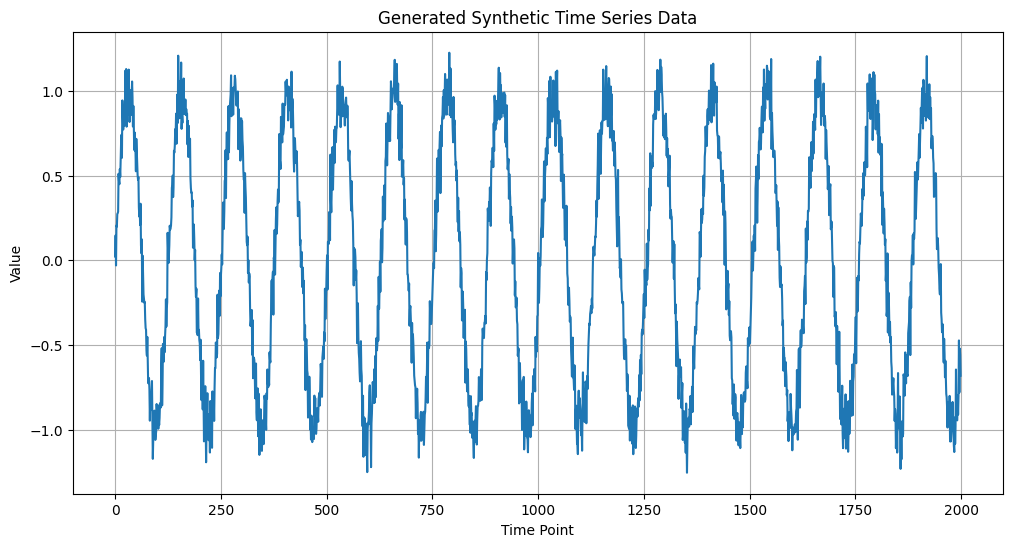

Generated time series data with 2000 points.


In [ ]:
# Generate synthetic time series data
def generate_time_series(num_points, freq=0.05, noise_level=0.1):
    time = np.arange(num_points)
    series = np.sin(time * freq) + np.random.normal(scale=noise_level, size=num_points)
    return series

num_data_points = 2000
time_series_data = generate_time_series(num_data_points)

# Visualize the generated data
plt.figure(figsize=(12, 6))
plt.plot(time_series_data)
plt.title("Generated Synthetic Time Series Data")
plt.xlabel("Time Point")
plt.ylabel("Value")
plt.grid(True)
plt.show()

print(f"Generated time series data with {len(time_series_data)} points.")

### 3. Preprocess the Data

Original data shape: (2000,)
Scaled data shape: (2000, 1)
First 5 original values: [ 0.02159666  0.14665265 -0.03113068  0.20543993  0.19792025]
First 5 scaled values: [0.51473622 0.56516782 0.49347275 0.5888751  0.58584262]


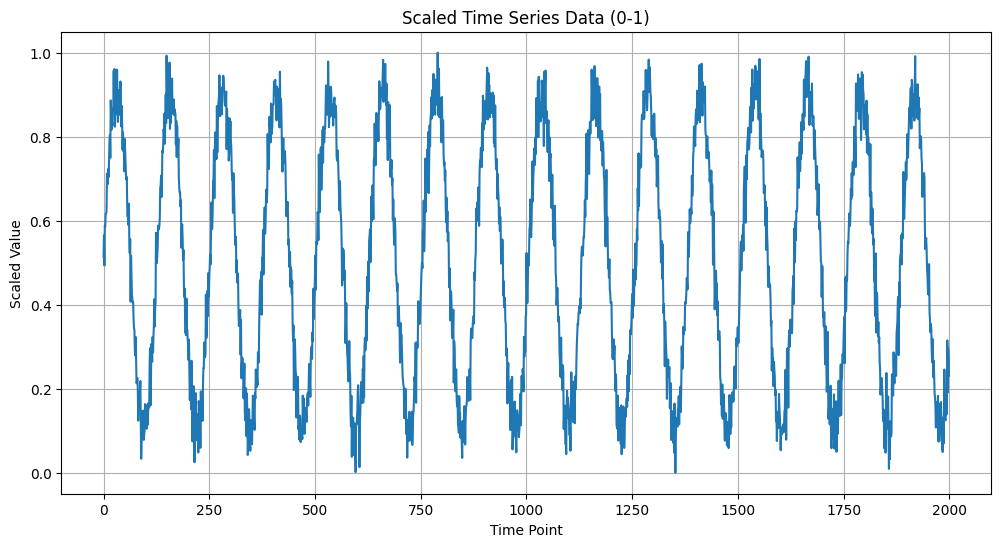

In [ ]:
# Reshape data for MinMaxScaler (needs 2D array: n_samples, n_features)
data_reshaped = time_series_data.reshape(-1, 1)

# Initialize MinMaxScaler and scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_reshaped)

print(f"Original data shape: {time_series_data.shape}")
print(f"Scaled data shape: {scaled_data.shape}")
print(f"First 5 original values: {time_series_data[:5]}")
print(f"First 5 scaled values: {scaled_data[:5].flatten()}")

# Visualize the scaled data
plt.figure(figsize=(12, 6))
plt.plot(scaled_data)
plt.title("Scaled Time Series Data (0-1)")
plt.xlabel("Time Point")
plt.ylabel("Scaled Value")
plt.grid(True)
plt.show()

### 4. Create Input Sequences

In [ ]:
def create_sequences(data, timesteps):
    X = []
    for i in range(len(data) - timesteps):
        X.append(data[i:(i + timesteps)])
    return np.array(X)

# Define the number of timesteps for each input sequence
TIMESTEPS = 50 # This means each input sequence will contain 50 consecutive data points

# Create input sequences
X_train = create_sequences(scaled_data, TIMESTEPS)

# For an autoencoder, the input and output are the same
y_train = X_train

print(f"Original scaled data shape: {scaled_data.shape}")
print(f"Input sequences (X_train) shape: {X_train.shape}")
print(f"Output sequences (y_train) shape: {y_train.shape}")

# Expected shape for LSTM: (samples, timesteps, features)
# In our case, features is 1 since it's a univariate time series.

Original scaled data shape: (2000, 1)
Input sequences (X_train) shape: (1950, 50, 1)
Output sequences (y_train) shape: (1950, 50, 1)


### 5. Build LSTM Autoencoder Model

In [ ]:
def build_lstm_autoencoder(timesteps, n_features):
    model = keras.Sequential([
        layers.Input(shape=(timesteps, n_features)),
        layers.LSTM(128, activation='relu', return_sequences=True),
        layers.LSTM(64, activation='relu', return_sequences=False),
        layers.RepeatVector(timesteps),
        layers.LSTM(64, activation='relu', return_sequences=True),
        layers.LSTM(128, activation='relu', return_sequences=True),
        layers.TimeDistributed(layers.Dense(n_features))
    ])
    return model

# Number of features in our time series (univariate, so 1)
N_FEATURES = 1

# Build the autoencoder model
model = build_lstm_autoencoder(TIMESTEPS, N_FEATURES)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 50, 1)          │           129 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 247,937 (968.50 KB)

 Trainable params: 247,937 (968.50 KB)

 Non-trainable params: 0 (0.00 B)

### 6. Compile & Train the Model

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - loss: 0.1831 - val_loss: 0.1018
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0816 - val_loss: 0.0782
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0685 - val_loss: 0.0698
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0605 - val_loss: 0.0594
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0494 - val_loss: 0.0460
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0407 - val_loss: 0.0375
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0326 - val_loss: 0.0299
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0298 - val_loss: 0.0259
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0223 - val_loss: 0.0238
Epoch 10/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0244 - val_loss: 0.0202
Epoch 11/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0158 - val_loss: 0.0151
Epoch 12/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.01

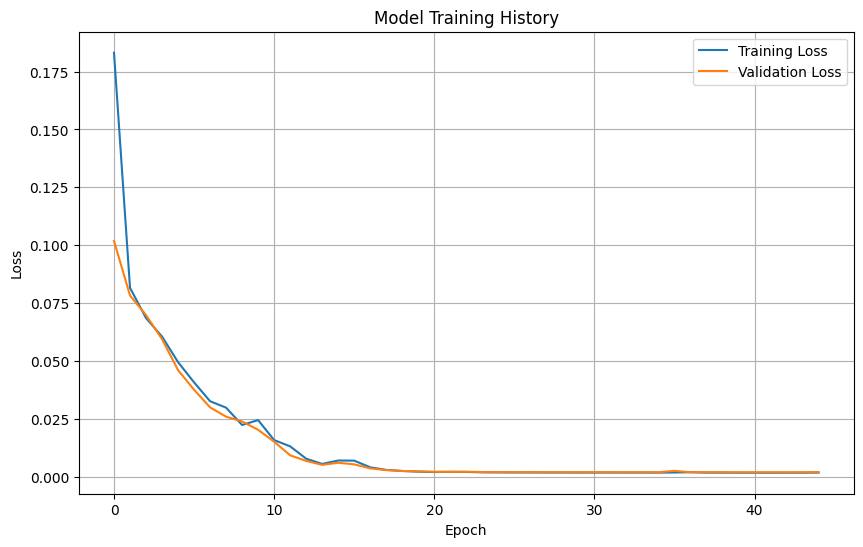

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='mse')

# Define training parameters
EPOCHS = 50
BATCH_SIZE = 128

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1, # Use 10% of training data for validation
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, mode='min')],
    verbose=1
)

# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### 7. Reconstruct the Input Sequence

61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step
Shape of original input sequences (X_train): (1950, 50, 1)
Shape of reconstructed sequences: (1950, 50, 1)


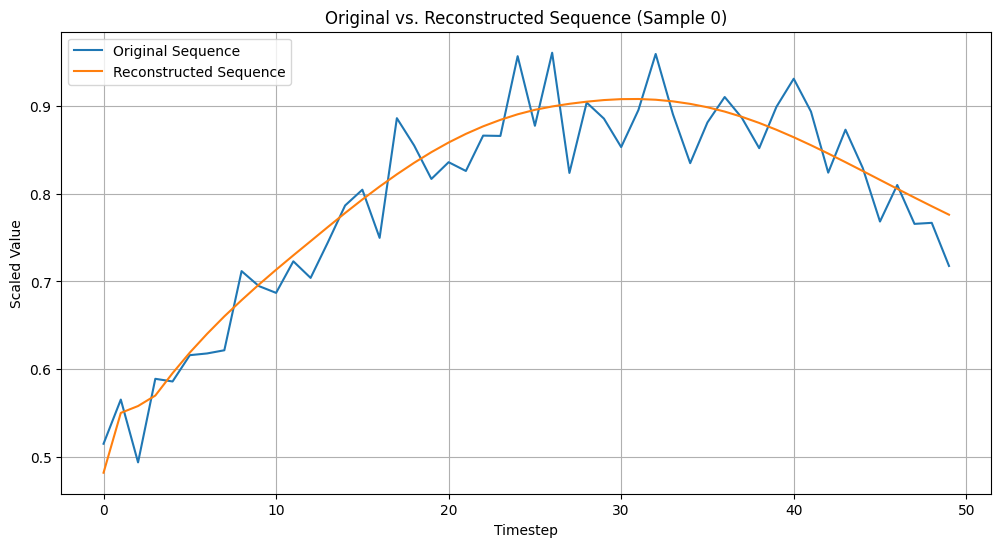

In [ ]:
# Reconstruct the input sequences using the trained model
reconstructed_sequences = model.predict(X_train)

print(f"Shape of original input sequences (X_train): {X_train.shape}")
print(f"Shape of reconstructed sequences: {reconstructed_sequences.shape}")

# Display a comparison of an original and reconstructed sequence
# We'll pick an arbitrary sequence, e.g., the first one
sample_index = 0
original_sample = X_train[sample_index].flatten()
reconstructed_sample = reconstructed_sequences[sample_index].flatten()

plt.figure(figsize=(12, 6))
plt.plot(original_sample, label='Original Sequence')
plt.plot(reconstructed_sample, label='Reconstructed Sequence')
plt.title(f'Original vs. Reconstructed Sequence (Sample {sample_index})')
plt.xlabel('Timestep')
plt.ylabel('Scaled Value')
plt.legend()
plt.grid(True)
plt.show()

### 8. Calculate Reconstruction Error

Shape of reconstruction errors: (1950,)
Minimum reconstruction error: 0.0239
Maximum reconstruction error: 0.0421
Average reconstruction error: 0.0336


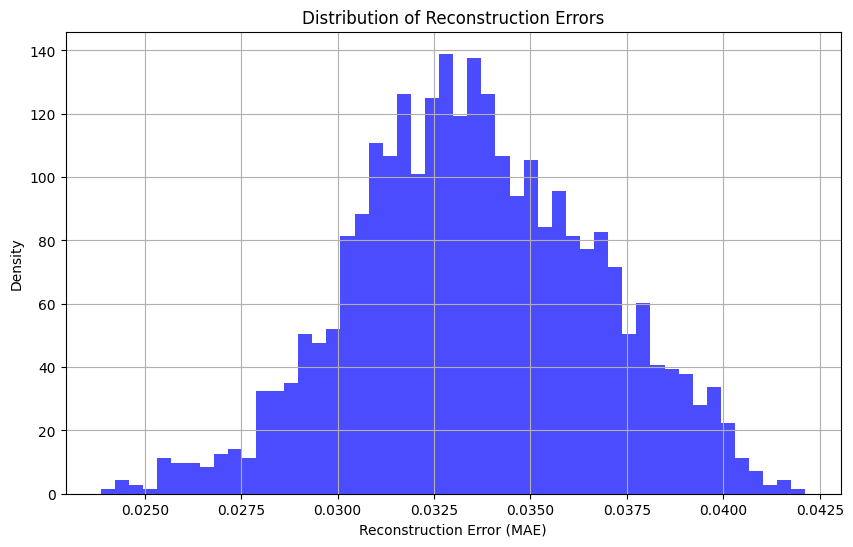

In [ ]:
# Calculate the reconstruction error (Mean Absolute Error)
reconstruction_errors = np.mean(np.abs(X_train - reconstructed_sequences), axis=(1, 2))

print(f"Shape of reconstruction errors: {reconstruction_errors.shape}")
print(f"Minimum reconstruction error: {np.min(reconstruction_errors):.4f}")
print(f"Maximum reconstruction error: {np.max(reconstruction_errors):.4f}")
print(f"Average reconstruction error: {np.mean(reconstruction_errors):.4f}")

# Visualize the distribution of reconstruction errors
plt.figure(figsize=(10, 6))
plt.hist(reconstruction_errors, bins=50, density=True, alpha=0.7, color='blue')
plt.title('Distribution of Reconstruction Errors')
plt.xlabel('Reconstruction Error (MAE)')
plt.ylabel('Density')
plt.grid(True)
plt.show()

# A threshold can be set based on this distribution to identify anomalies.

### 9. Visualize Original & Reconstructed Sequences (and Anomalies)

In the context of autoencoders for time series anomaly detection:

*   **Original Sequence (or Collisional Sequence, if anomalous):** This refers to the raw, input time series segment that the autoencoder receives. If this segment represents an anomalous pattern, it can be thought of as a 'collisional' sequence because it deviates from what the model considers 'normal'.
*   **Reconstructed Sequence:** This is the output of the autoencoder, the model's best attempt to reproduce the original input sequence after compressing and decompressing it through its hidden layers. For normal patterns, the reconstructed sequence should closely match the original. For anomalous patterns, the reconstruction will likely be poor, leading to a high reconstruction error.

We will now visualize several examples to see the difference between normal and potentially anomalous reconstructions.

Anomaly threshold set at the 95th percentile: 0.0390
Found 98 potential anomalies based on the threshold.

--- Visualizing Normal Sequences ---


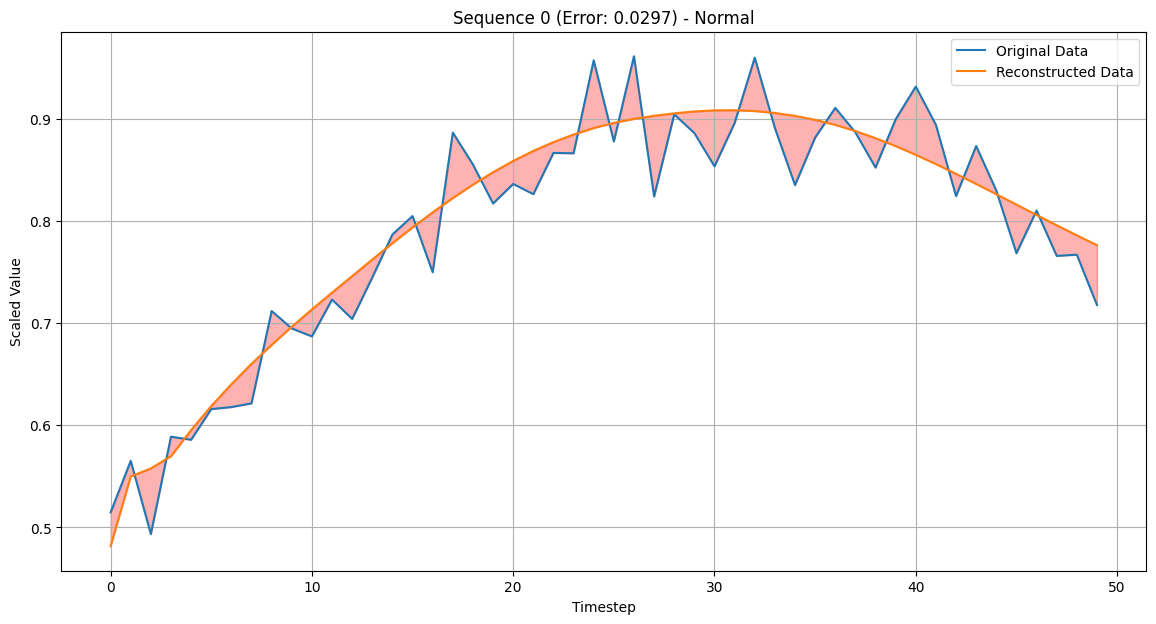

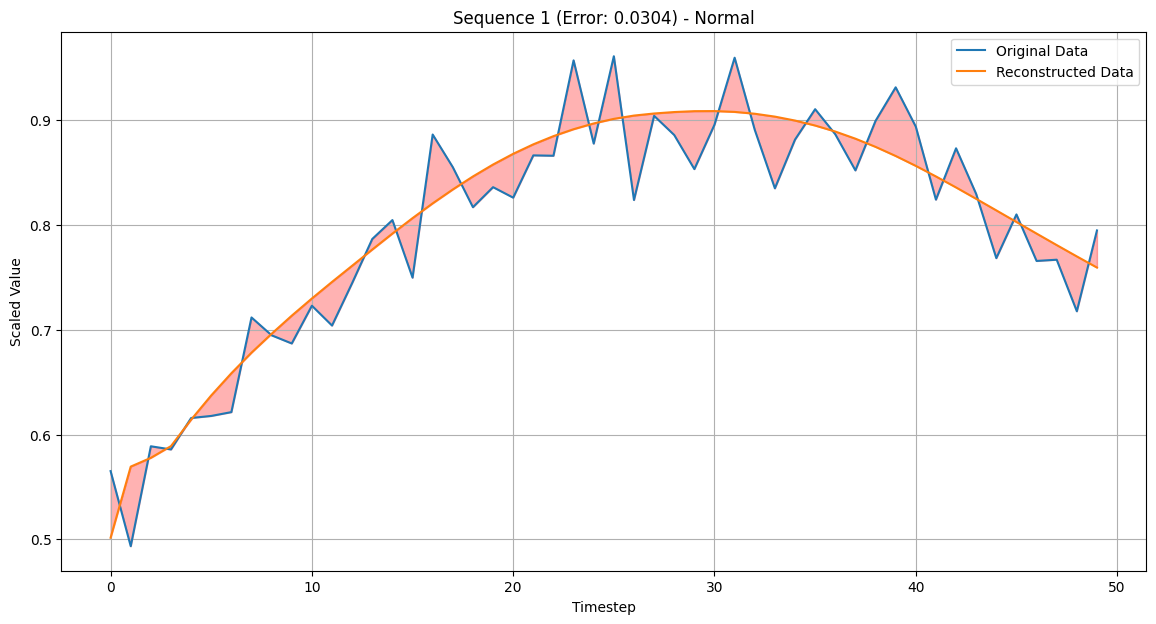

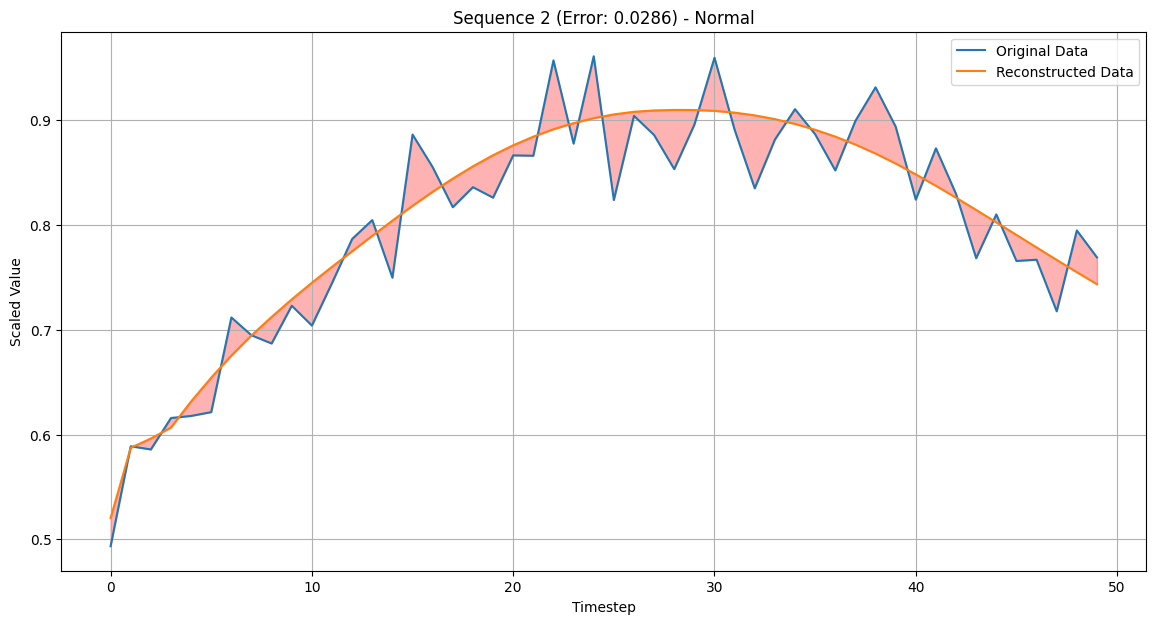


--- Visualizing Anomalous Sequences ---


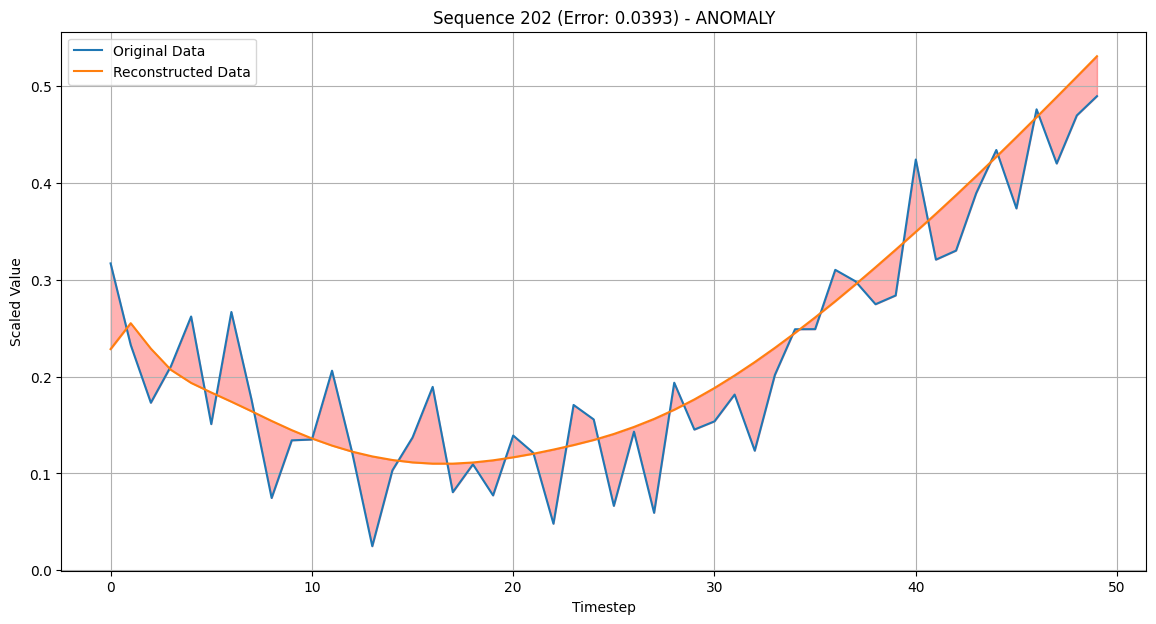

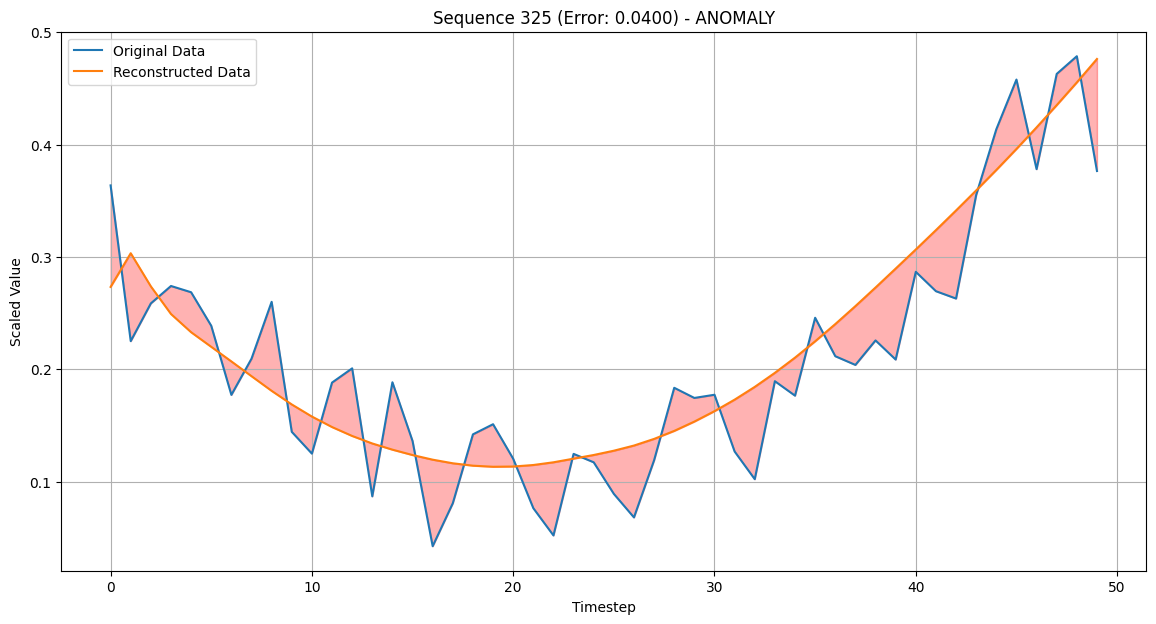

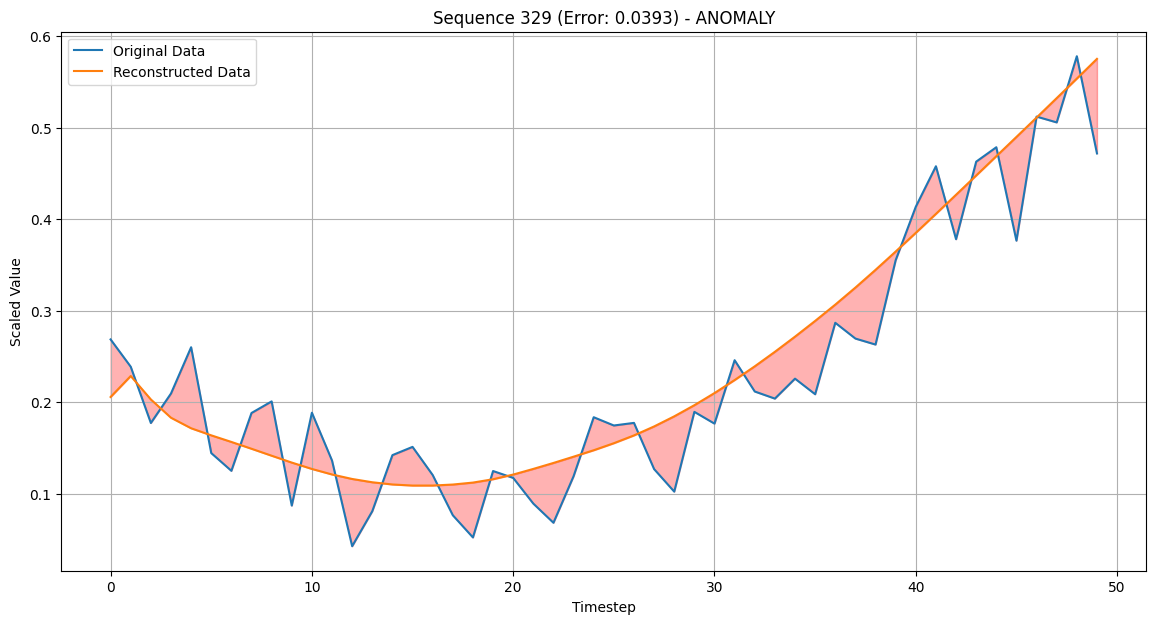

In [ ]:
# Set a threshold for anomaly detection (e.g., 95th percentile of errors)
THRESHOLD = np.percentile(reconstruction_errors, 95)
print(f"Anomaly threshold set at the 95th percentile: {THRESHOLD:.4f}")

# Find indices of sequences with high reconstruction error (potential anomalies)
anomaly_indices = np.where(reconstruction_errors > THRESHOLD)[0]
print(f"Found {len(anomaly_indices)} potential anomalies based on the threshold.")

# Function to plot original, reconstructed, and highlight anomalies
def plot_reconstruction(index, is_anomaly=False):
    original = X_train[index].flatten()
    reconstructed = reconstructed_sequences[index].flatten()
    error = reconstruction_errors[index]

    plt.figure(figsize=(14, 7))
    plt.plot(original, label='Original Data')
    plt.plot(reconstructed, label='Reconstructed Data')
    plt.title(f'Sequence {index} (Error: {error:.4f}) - ' + ('ANOMALY' if is_anomaly else 'Normal'))
    plt.xlabel('Timestep')
    plt.ylabel('Scaled Value')
    plt.legend()
    plt.grid(True)
    plt.fill_between(range(len(original)), original, reconstructed, color='red', alpha=0.3, label='Reconstruction Error Area')
    plt.show()

# Plot a few normal sequences
print("\n--- Visualizing Normal Sequences ---")
for i in range(3):
    # Find a non-anomaly index
    normal_indices = np.where(reconstruction_errors <= THRESHOLD)[0]
    if len(normal_indices) > i:
        plot_reconstruction(normal_indices[i], is_anomaly=False)

# Plot a few anomalous sequences (if any are found)
if len(anomaly_indices) > 0:
    print("\n--- Visualizing Anomalous Sequences ---")
    for i in range(min(3, len(anomaly_indices))):
        plot_reconstruction(anomaly_indices[i], is_anomaly=True)
else:
    print("\nNo anomalies found above the set threshold in the training data.")

### 10. Load a New Real-World Dataset

Now, let's load a real-world dataset to apply our anomaly detection pipeline. Please specify the path to your dataset below. We'll assume it's a CSV file, but if it's in another format, you might need a different loading function.

In [ ]:
# Specify the path to your real-world time series dataset
# Replace 'your_real_world_data.csv' with the actual file path
data_path = '/content/sample_data/california_housing_train.csv'

try:
    # Load the dataset using pandas
    # You might need to adjust parameters like 'parse_dates', 'index_col', etc., depending on your data
    df = pd.read_csv(data_path)
    print(f"Successfully loaded data from {data_path}")

    # Display the first few rows of the dataframe
    print("\nFirst 5 rows of the dataset:")
    display(df.head())

    # Display basic information about the dataframe, including data types and non-null values
    print("\nDataset Information:")
    df.info()

    # Assuming the time series column is the one we want to analyze, we'll need to select it.
    # For simplicity, let's assume the numerical column we want to analyze is named 'value'.
    # You'll likely need to adjust this based on your actual dataset.
    # If your dataset has multiple columns and you want to analyze one, select it here.
    # For example, if your time series data is in a column named 'sensor_reading':
    # time_series_data_new = df['sensor_reading'].values

    # For the California Housing dataset, we'll select 'median_house_value' as an example.
    # You can change this to another numerical column if you prefer.
    selected_column = 'median_house_value'
    if selected_column in df.columns:
        time_series_data = df[selected_column].values
        print(f"\nSelected '{selected_column}' as the univariate time series data.")
        print(f"First 5 values of selected time series: {time_series_data[:5]}")
    else:
        print(f"Error: The selected column '{selected_column}' was not found in the dataset.")
        print("Available columns:", df.columns.tolist())
        time_series_data = None # User needs to select a valid column

except FileNotFoundError:
    print(f"Error: The file '{data_path}' was not found. Please ensure the path is correct and the file exists.")
except Exception as e:
    print(f"An error occurred while loading or processing the data: {e}")

Successfully loaded data from /content/sample_data/california_housing_train.csv

First 5 rows of the dataset:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB

Selected 'median_house_value' as the univariate time series data.
First 5 values of selected time series: [66900. 80100. 85700. 73400. 65500.]


### 11. Preprocess the New Real-World Data

Now that we have loaded the `time_series_data` from the real-world dataset, we need to preprocess it. This involves scaling the data to a range between 0 and 1 using `MinMaxScaler`.

Original new data shape: (17000,)
Scaled new data shape: (17000, 1)
First 5 original new values: [66900. 80100. 85700. 73400. 65500.]
First 5 scaled new values: [0.10701193 0.13422831 0.14577466 0.12041394 0.10412534]


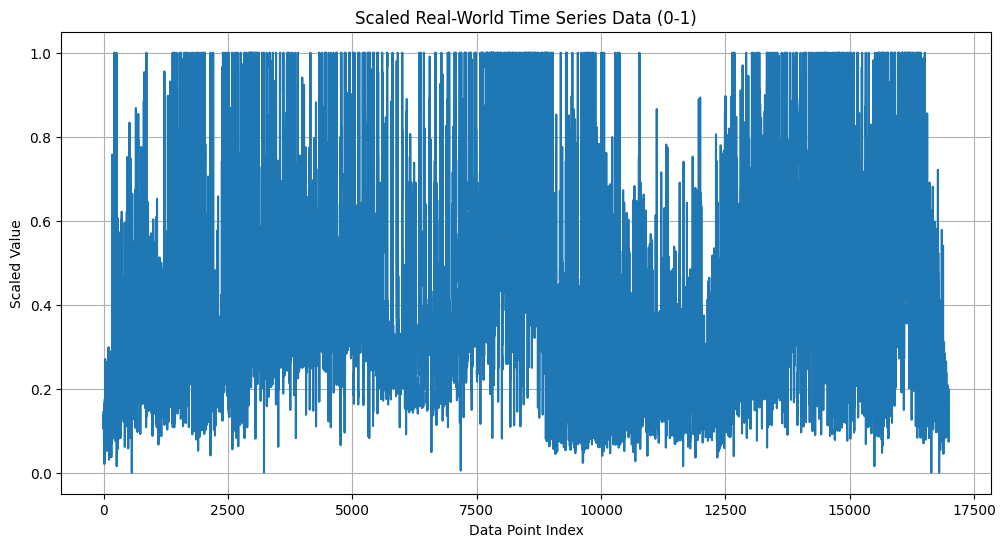

In [ ]:
# Reshape data for MinMaxScaler (needs 2D array: n_samples, n_features)
# Ensure time_series_data is not None from previous step
if time_series_data is not None:
    data_reshaped_new = time_series_data.reshape(-1, 1)

    # Initialize MinMaxScaler and scale the data
    scaler_new = MinMaxScaler(feature_range=(0, 1))
    scaled_data_new = scaler_new.fit_transform(data_reshaped_new)

    print(f"Original new data shape: {time_series_data.shape}")
    print(f"Scaled new data shape: {scaled_data_new.shape}")
    print(f"First 5 original new values: {time_series_data[:5]}")
    print(f"First 5 scaled new values: {scaled_data_new[:5].flatten()}")

    # Visualize the scaled data
    plt.figure(figsize=(12, 6))
    plt.plot(scaled_data_new)
    plt.title("Scaled Real-World Time Series Data (0-1)")
    plt.xlabel("Data Point Index")
    plt.ylabel("Scaled Value")
    plt.grid(True)
    plt.show()
else:
    print("Error: time_series_data was not properly loaded in the previous step. Please check the column selection.")

### 12. Create Input Sequences for the New Data

Next, we will transform the scaled real-world data into sequences using the same `create_sequences` function and `TIMESTEPS` value as before. This will generate `X_train_new` and `y_train_new` for our autoencoder.

In [ ]:
# Define the number of timesteps for each input sequence (using the same TIMESTEPS as before)
# TIMESTEPS = 50 # This variable is already defined globally

# Create input sequences from the new scaled data
if 'scaled_data_new' in locals() and scaled_data_new is not None:
    X_train_new = create_sequences(scaled_data_new, TIMESTEPS)

    # For an autoencoder, the input and output are the same
    y_train_new = X_train_new

    print(f"Original scaled new data shape: {scaled_data_new.shape}")
    print(f"Input sequences (X_train_new) shape: {X_train_new.shape}")
    print(f"Output sequences (y_train_new) shape: {y_train_new.shape}")

    # Expected shape for LSTM: (samples, timesteps, features)
    # In our case, features is 1 since it's a univariate time series.
else:
    print("Error: scaled_data_new was not properly created. Please check the preprocessing step.")

Original scaled new data shape: (17000, 1)
Input sequences (X_train_new) shape: (16950, 50, 1)
Output sequences (y_train_new) shape: (16950, 50, 1)


### 13. Build and Train the LSTM Autoencoder Model on New Data

We will now build a new instance of our LSTM autoencoder model and train it using the `X_train_new` and `y_train_new` sequences derived from the California Housing dataset.

Model summary for the new autoencoder:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 50, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 50, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 50, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 50, 1)          │           129 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 247,937 (968.50 KB)

 Trainable params: 247,937 (968.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 31s 136ms/step - loss: 0.0573 - val_loss: 0.0479
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0393 - val_loss: 0.0665
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0397 - val_loss: 0.0441
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0374 - val_loss: 0.0439
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0351 - val_loss: 0.0424
Epoch 6/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0336 - val_loss: 0.0413
Epoch 7/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0326 - val_loss: 0.0401
Epoch 8/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0380 - val_loss: 0.1037
Epoch 9/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0464 - val_loss: 0.0451
Epoch 10/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0367 - val_loss: 0.0442
Epoch 11/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0341 - val_loss: 0.0410
Epoch 12/50
120/120 ━━━━━━━━━━━━━━━━━━━

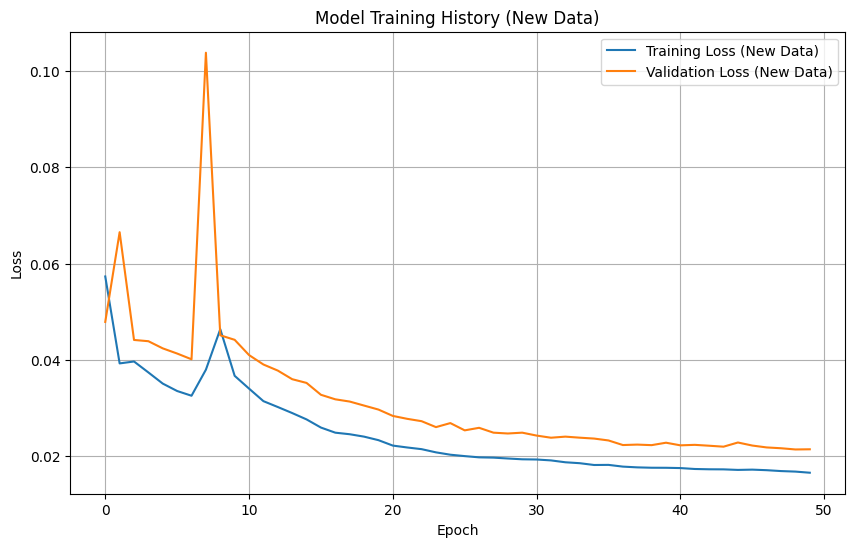

In [ ]:
# Build a new instance of the autoencoder model
model_new = build_lstm_autoencoder(TIMESTEPS, N_FEATURES)

print("Model summary for the new autoencoder:")
model_new.summary()

# Compile the new model (using the same optimizer and loss)
model_new.compile(optimizer='adam', loss='mse')

# Train the new model
history_new = model_new.fit(
    X_train_new,
    y_train_new,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1, # Use 10% of new training data for validation
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, mode='min')],
    verbose=1
)

# Plot training history for the new model
plt.figure(figsize=(10, 6))
plt.plot(history_new.history['loss'], label='Training Loss (New Data)')
plt.plot(history_new.history['val_loss'], label='Validation Loss (New Data)')
plt.title('Model Training History (New Data)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### 14. Reconstruct Sequences with the New Model

Now we'll use the `model_new` trained on the California Housing data to reconstruct the `X_train_new` sequences.

530/530 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step
Shape of original input sequences (X_train_new): (16950, 50, 1)
Shape of reconstructed sequences (new data): (16950, 50, 1)


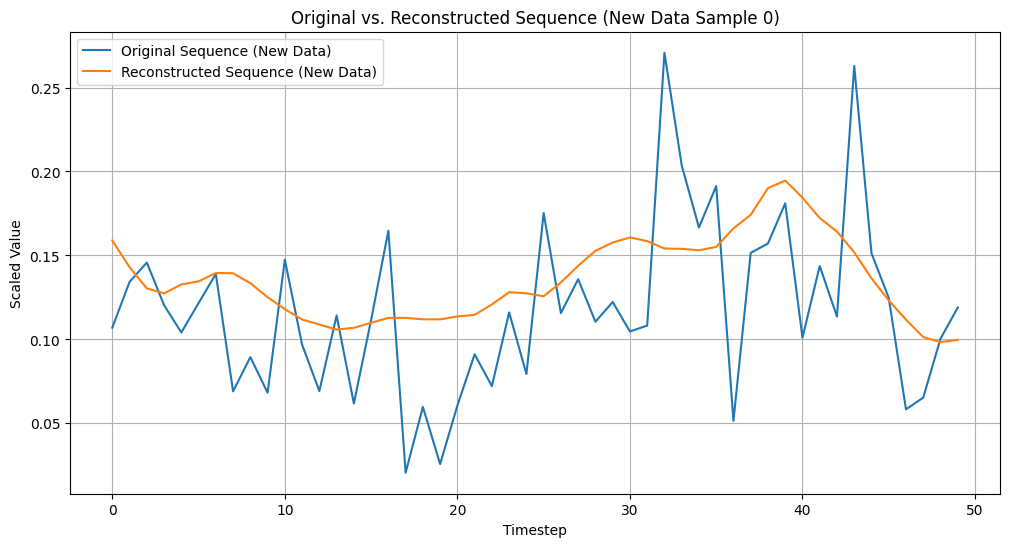

In [ ]:
# Reconstruct the input sequences using the newly trained model
reconstructed_sequences_new = model_new.predict(X_train_new)

print(f"Shape of original input sequences (X_train_new): {X_train_new.shape}")
print(f"Shape of reconstructed sequences (new data): {reconstructed_sequences_new.shape}")

# Display a comparison of an original and reconstructed sequence from the new data
# We'll pick an arbitrary sequence, e.g., the first one
sample_index_new = 0
original_sample_new = X_train_new[sample_index_new].flatten()
reconstructed_sample_new = reconstructed_sequences_new[sample_index_new].flatten()

plt.figure(figsize=(12, 6))
plt.plot(original_sample_new, label='Original Sequence (New Data)')
plt.plot(reconstructed_sample_new, label='Reconstructed Sequence (New Data)')
plt.title(f'Original vs. Reconstructed Sequence (New Data Sample {sample_index_new})')
plt.xlabel('Timestep')
plt.ylabel('Scaled Value')
plt.legend()
plt.grid(True)
plt.show()

### 15. Calculate Reconstruction Error for New Data

We will now calculate the Mean Absolute Error (MAE) between the original and reconstructed sequences for the California Housing data.

Shape of reconstruction errors (new data): (16950,)
Minimum reconstruction error (new data): 0.0168
Maximum reconstruction error (new data): 0.2257
Average reconstruction error (new data): 0.0923


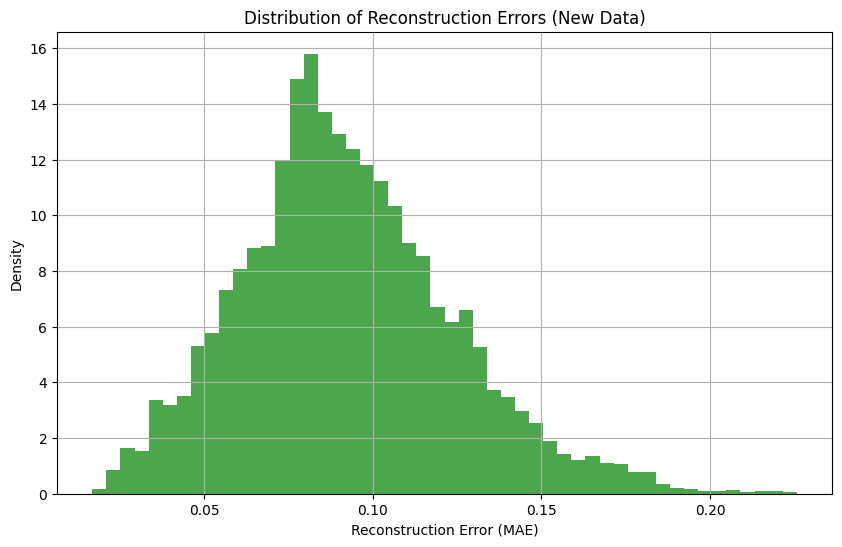

In [ ]:
# Calculate the reconstruction error (Mean Absolute Error) for the new data
reconstruction_errors_new = np.mean(np.abs(X_train_new - reconstructed_sequences_new), axis=(1, 2))

print(f"Shape of reconstruction errors (new data): {reconstruction_errors_new.shape}")
print(f"Minimum reconstruction error (new data): {np.min(reconstruction_errors_new):.4f}")
print(f"Maximum reconstruction error (new data): {np.max(reconstruction_errors_new):.4f}")
print(f"Average reconstruction error (new data): {np.mean(reconstruction_errors_new):.4f}")

# Visualize the distribution of reconstruction errors for the new data
plt.figure(figsize=(10, 6))
plt.hist(reconstruction_errors_new, bins=50, density=True, alpha=0.7, color='green')
plt.title('Distribution of Reconstruction Errors (New Data)')
plt.xlabel('Reconstruction Error (MAE)')
plt.ylabel('Density')
plt.grid(True)
plt.show()

### 16. Visualize Original & Reconstructed Sequences (and Anomalies) for New Data

Finally, we will set an anomaly threshold based on the reconstruction errors of the new data and visualize some normal and potentially anomalous sequences.

### 17. Evaluate Model with Injected Anomalies

To evaluate the model quantitatively, we need a dataset with known anomalies. Since we don't have pre-labeled anomalies for the California Housing data, we'll create a synthetic test set by injecting anomalies into a portion of the existing data.

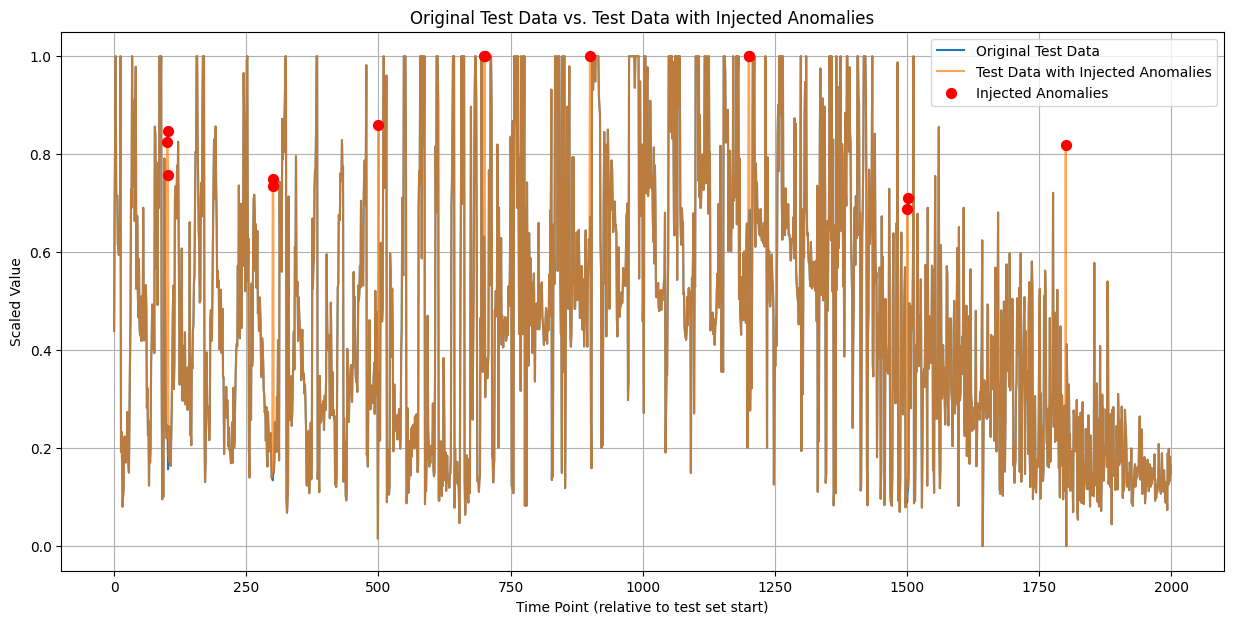

Test data length: 2000 points.
Number of injected anomaly points: 14


In [ ]:
# Take a portion of the scaled_data_new to create a test set for evaluation
# We'll use the last 2000 points as a test set for injecting anomalies
test_data_start_index = len(scaled_data_new) - 2000
test_data_original = scaled_data_new[test_data_start_index:].copy()

# Create a copy to inject anomalies into
test_data_with_anomalies = test_data_original.copy()

# Define a function to inject anomalies
def inject_anomalies(data, anomaly_locations, anomaly_magnitude=0.5):
    for loc in anomaly_locations:
        # Ensure location is within bounds and apply a noticeable spike
        if 0 <= loc < len(data):
            data[loc] = data[loc] + anomaly_magnitude
            # Clip to [0,1] range if it goes out of bounds due to anomaly
            data[loc] = np.clip(data[loc], 0, 1)
    return data

# Manually define locations for injecting anomalies in the test data
# These locations are within the test_data_with_anomalies array
# Example: inject anomalies at indices 100, 300, 500, 700, 900 relative to the test_data_with_anomalies
injected_anomaly_points = [100, 101, 102, 300, 301, 500, 700, 701, 900, 1200, 1201, 1500, 1501, 1800]
injected_anomaly_magnitude = 0.6

test_data_with_anomalies = inject_anomalies(test_data_with_anomalies, injected_anomaly_points, injected_anomaly_magnitude)

# Visualize original test data vs. test data with injected anomalies
plt.figure(figsize=(15, 7))
plt.plot(test_data_original, label='Original Test Data')
plt.plot(test_data_with_anomalies, label='Test Data with Injected Anomalies', alpha=0.7)
plt.scatter(injected_anomaly_points, test_data_with_anomalies[injected_anomaly_points], color='red', s=50, zorder=5, label='Injected Anomalies')
plt.title('Original Test Data vs. Test Data with Injected Anomalies')
plt.xlabel('Time Point (relative to test set start)')
plt.ylabel('Scaled Value')
plt.legend()
plt.grid(True)
plt.show()

print(f"Test data length: {len(test_data_original)} points.")
print(f"Number of injected anomaly points: {len(injected_anomaly_points)}")

Now, we create sequences from this anomaly-injected test data and use the trained `model_new` to predict reconstructions and calculate errors.

61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step
Shape of X_test_anomalies: (1950, 50, 1)
Shape of reconstruction_errors_test: (1950,)


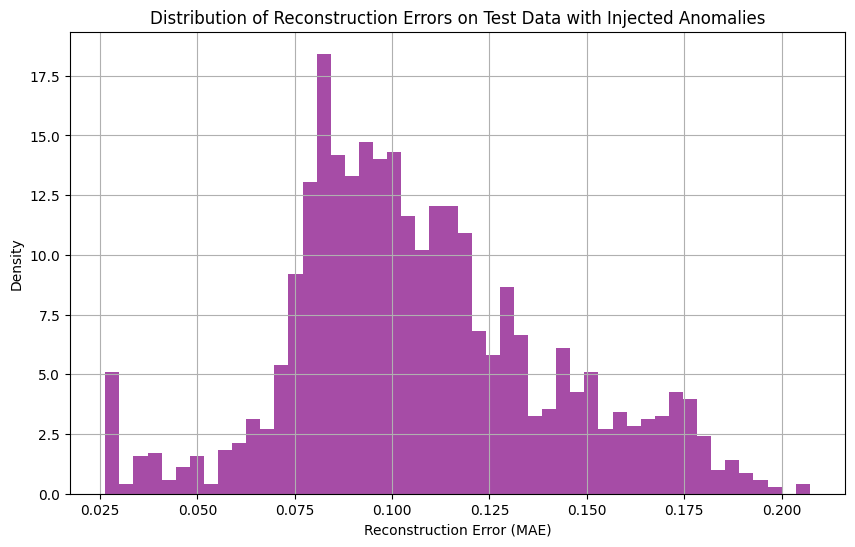

In [ ]:
# Create sequences from the test data with injected anomalies
X_test_anomalies = create_sequences(test_data_with_anomalies, TIMESTEPS)

# Predict reconstructions using model_new
reconstructed_test_sequences = model_new.predict(X_test_anomalies)

# Calculate reconstruction errors for the test data
reconstruction_errors_test = np.mean(np.abs(X_test_anomalies - reconstructed_test_sequences), axis=(1, 2))

print(f"Shape of X_test_anomalies: {X_test_anomalies.shape}")
print(f"Shape of reconstruction_errors_test: {reconstruction_errors_test.shape}")

# Visualize the distribution of reconstruction errors for the test data
plt.figure(figsize=(10, 6))
plt.hist(reconstruction_errors_test, bins=50, density=True, alpha=0.7, color='purple')
plt.title('Distribution of Reconstruction Errors on Test Data with Injected Anomalies')
plt.xlabel('Reconstruction Error (MAE)')
plt.ylabel('Density')
plt.grid(True)
plt.show()

We can now evaluate the model's ability to detect the injected anomalies using metrics like Precision, Recall, and F1-score.


Evaluation Metrics on Injected Anomalies:
Precision: 0.3730
Recall: 0.2315
F1-Score: 0.2857

Confusion Matrix components:
True Positives (correctly identified anomalies): 94
False Positives (normal sequences incorrectly flagged as anomalies): 158
False Negatives (anomalies missed by the model): 312
True Negatives (correctly identified normal sequences): 1386

--- Visualizing Injected Anomalies and Detections ---

--- True Positive Examples ---


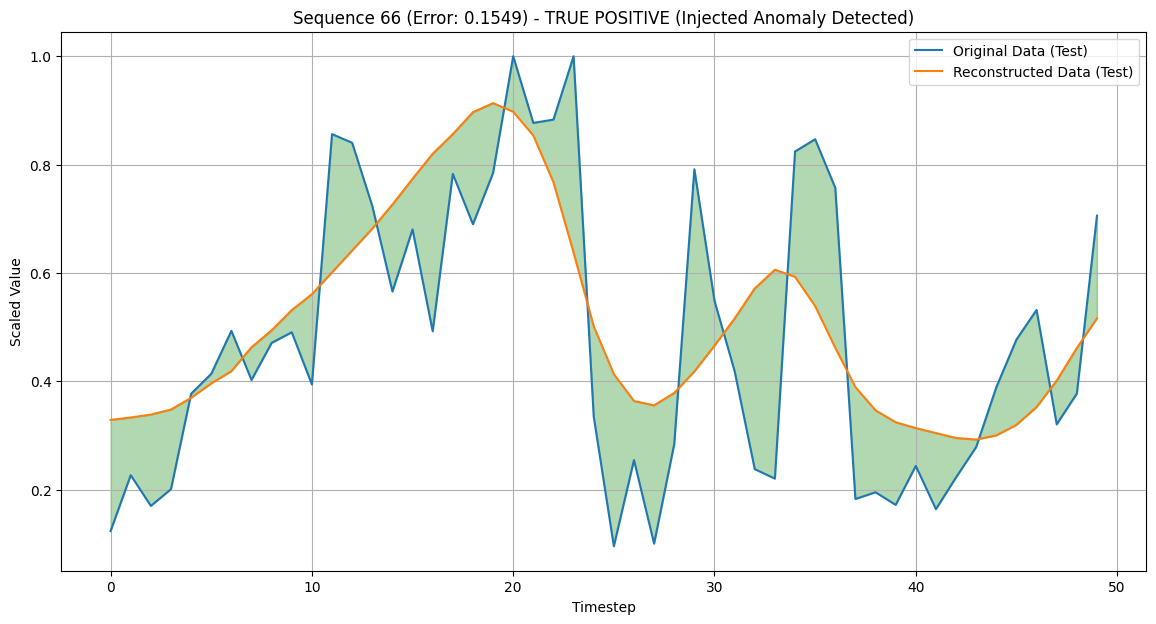

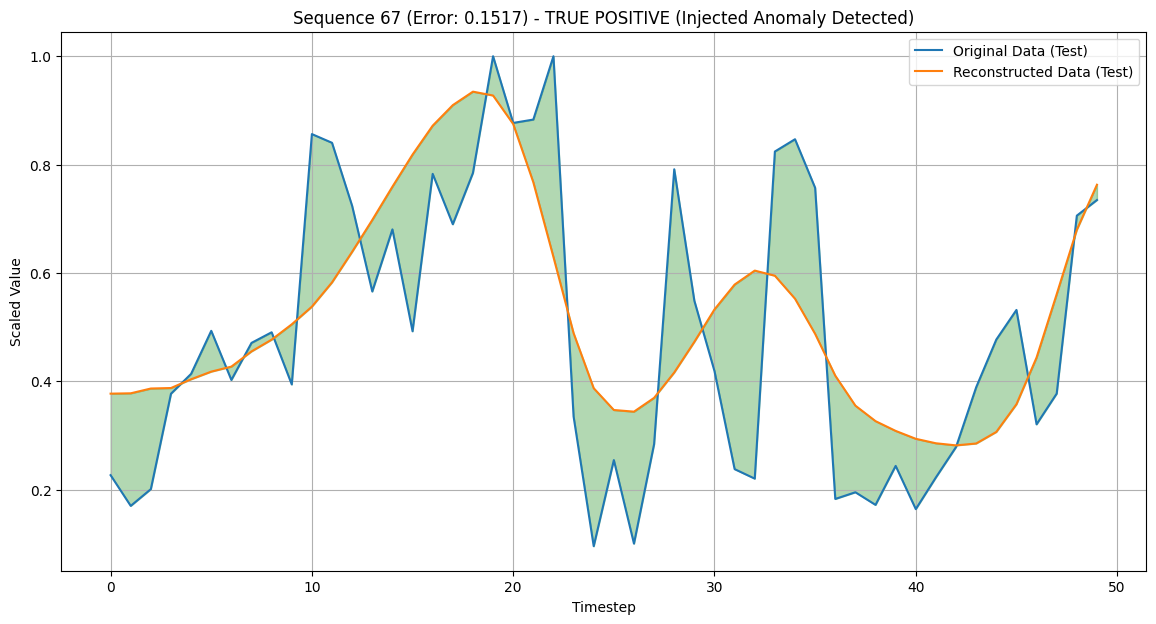


--- False Negative Examples (Missed Anomalies) ---


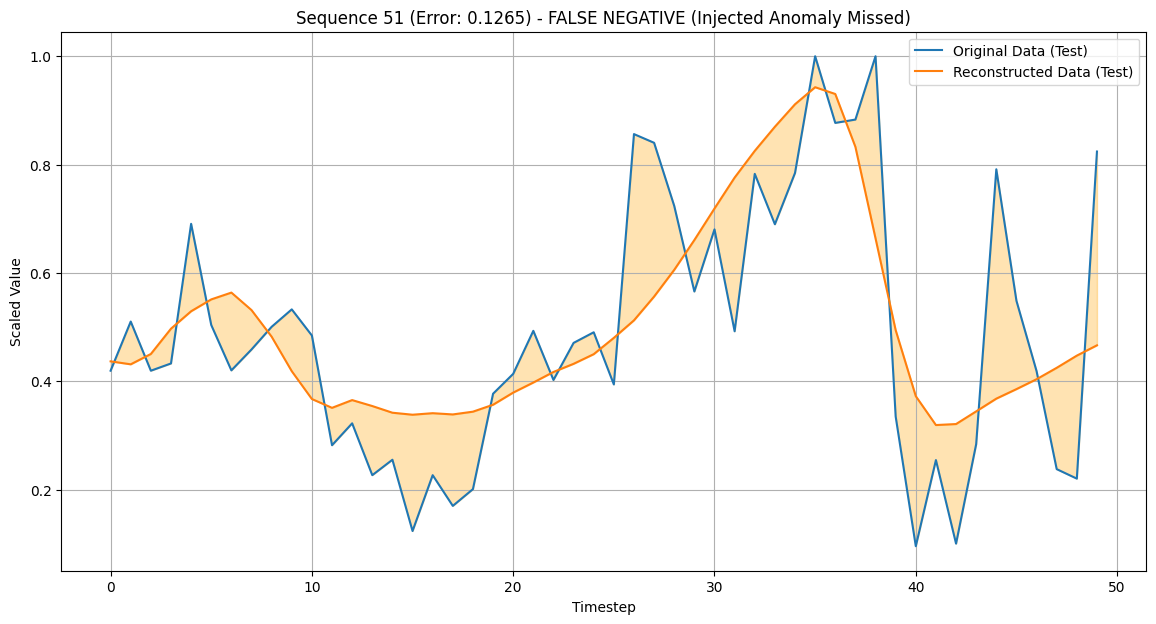

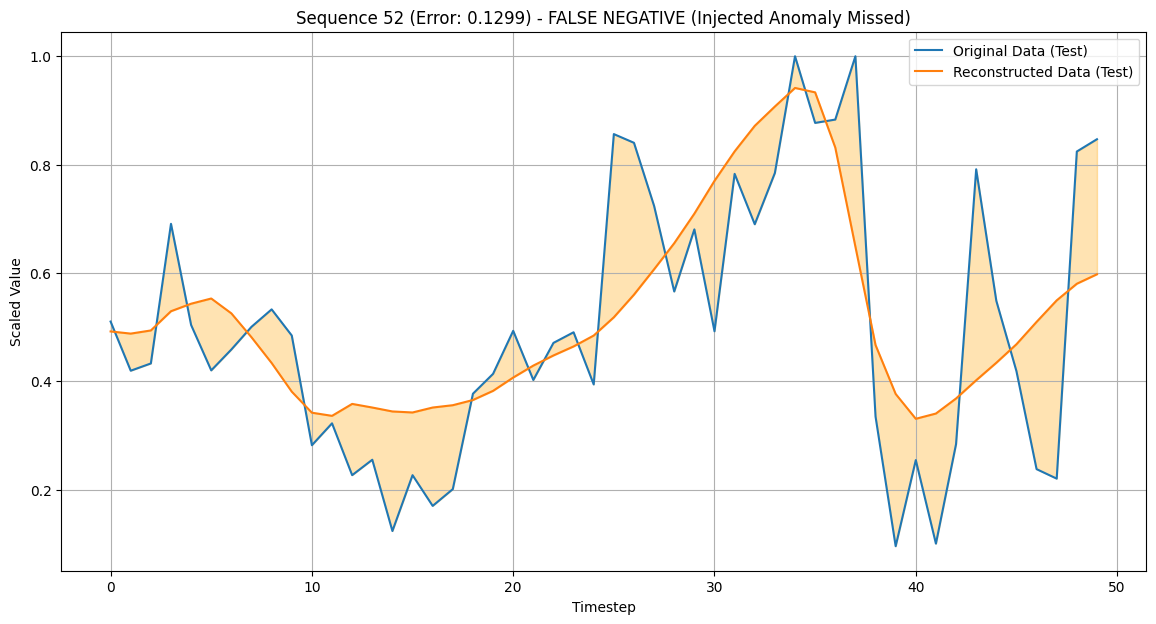


--- False Positive Examples (False Alarms) ---


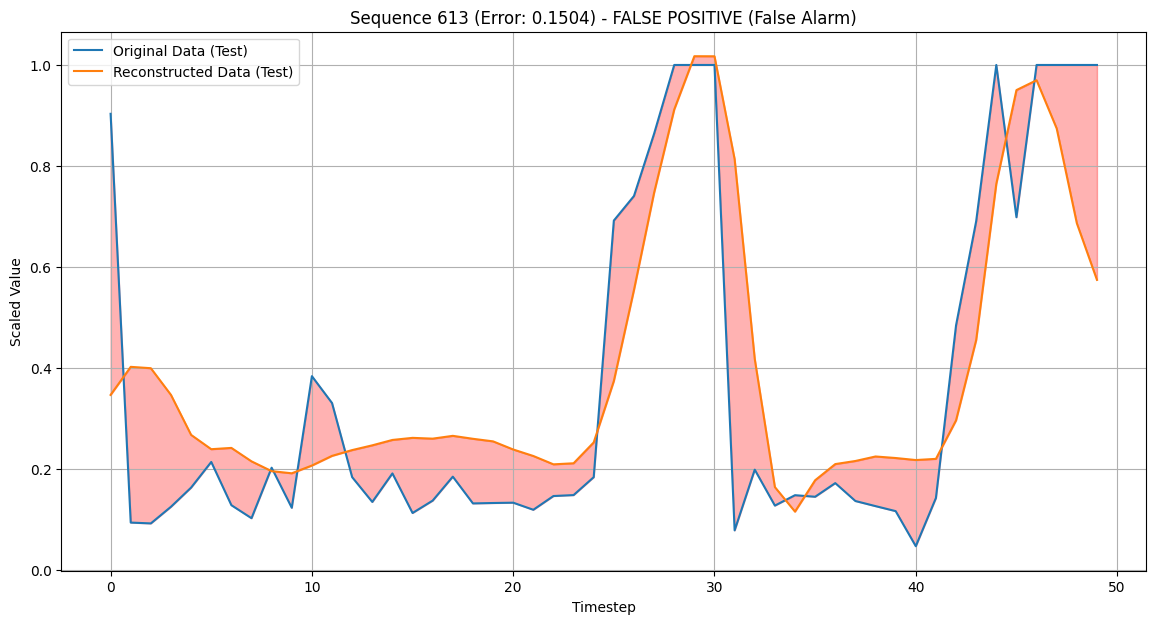

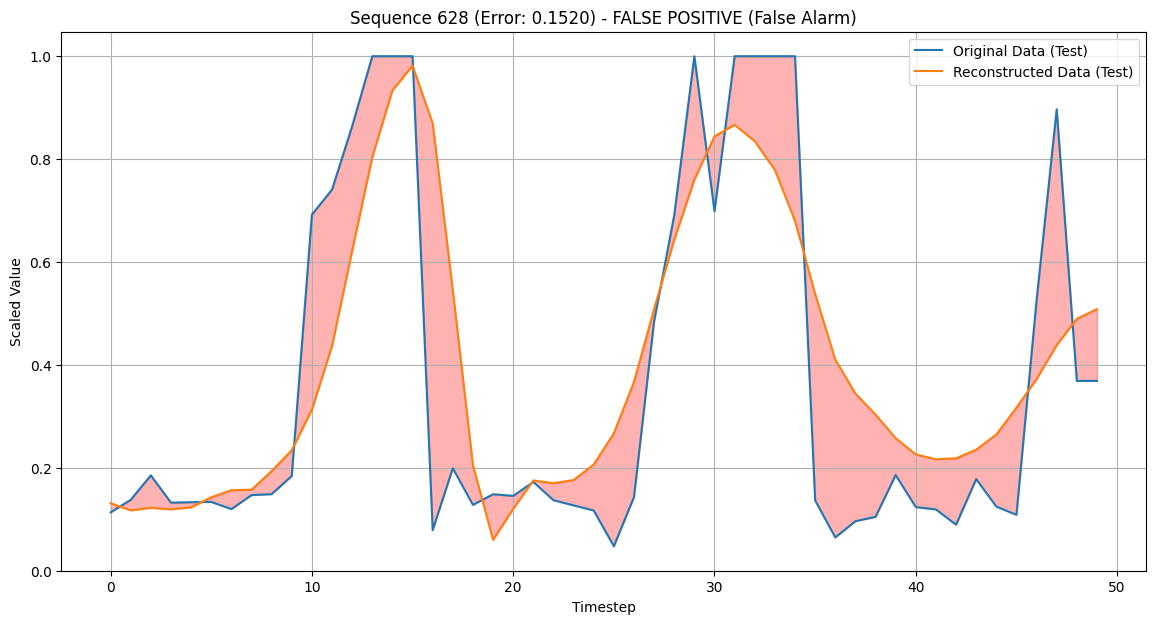

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Determine the threshold for anomaly detection on the test set
# We can use the same THRESHOLD_NEW determined from the training data or re-evaluate for the test data
# For consistent evaluation, let's use the THRESHOLD_NEW from the training phase.

# Classify predictions based on the threshold
y_pred_anomalies = (reconstruction_errors_test > THRESHOLD_NEW).astype(int)

# Create true labels for the injected anomalies
# A sequence is anomalous if any of its points overlap with an injected anomaly
y_true_anomalies = np.zeros(len(X_test_anomalies), dtype=int)

for i, seq_idx in enumerate(injected_anomaly_points):
    # An injected anomaly at 'seq_idx' affects sequences starting from 'seq_idx - TIMESTEPS + 1' to 'seq_idx'
    # We need to map the injected anomaly index (relative to test_data_original) to the sequence indices in X_test_anomalies
    # The actual index in `test_data_original` that contains the anomaly is `seq_idx`.
    # A sequence `X_test_anomalies[s_i]` contains data from `test_data_with_anomalies[s_i]` to `test_data_with_anomalies[s_i + TIMESTEPS - 1]`

    # Mark all sequences that *contain* an injected anomaly point as true anomalies.
    # The sequence starting at index `s_i` covers data points `s_i` through `s_i + TIMESTEPS - 1`.
    # If `seq_idx` falls within this window, then `X_test_anomalies[s_i]` is an anomaly.
    # The valid range of sequence indices for an anomaly at `seq_idx` in `test_data_with_anomalies` is:
    # `max(0, seq_idx - TIMESTEPS + 1)` to `min(len(X_test_anomalies) - 1, seq_idx)`

    # Iterate through the sequence indices that would contain this injected anomaly
    for s_idx in range(max(0, seq_idx - TIMESTEPS + 1), min(len(X_test_anomalies), seq_idx + 1)):
        y_true_anomalies[s_idx] = 1


# Calculate evaluation metrics
precision = precision_score(y_true_anomalies, y_pred_anomalies)
recall = recall_score(y_true_anomalies, y_pred_anomalies)
f1 = f1_score(y_true_anomalies, y_pred_anomalies)

print(f"\nEvaluation Metrics on Injected Anomalies:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Count true positives, false positives, false negatives
true_positives = np.sum((y_true_anomalies == 1) & (y_pred_anomalies == 1))
false_positives = np.sum((y_true_anomalies == 0) & (y_pred_anomalies == 1))
false_negatives = np.sum((y_true_anomalies == 1) & (y_pred_anomalies == 0))
true_negatives = np.sum((y_true_anomalies == 0) & (y_pred_anomalies == 0))

print(f"\nConfusion Matrix components:")
print(f"True Positives (correctly identified anomalies): {true_positives}")
print(f"False Positives (normal sequences incorrectly flagged as anomalies): {false_positives}")
print(f"False Negatives (anomalies missed by the model): {false_negatives}")
print(f"True Negatives (correctly identified normal sequences): {true_negatives}")

# Optional: Visualize some of the detected injected anomalies
print("\n--- Visualizing Injected Anomalies and Detections ---")

# Function to plot sequences with injected anomalies and model's detection
def plot_injected_anomaly_detection(index, is_true_anomaly, is_predicted_anomaly):
    original_test_seq = X_test_anomalies[index].flatten()
    reconstructed_test_seq = reconstructed_test_sequences[index].flatten()
    error = reconstruction_errors_test[index]

    plt.figure(figsize=(14, 7))
    plt.plot(original_test_seq, label='Original Data (Test)')
    plt.plot(reconstructed_test_seq, label='Reconstructed Data (Test)')
    title_text = f'Sequence {index} (Error: {error:.4f}) - '
    if is_true_anomaly and is_predicted_anomaly:
        title_text += 'TRUE POSITIVE (Injected Anomaly Detected)'
        fill_color = 'green'
    elif is_true_anomaly and not is_predicted_anomaly:
        title_text += 'FALSE NEGATIVE (Injected Anomaly Missed)'
        fill_color = 'orange'
    elif not is_true_anomaly and is_predicted_anomaly:
        title_text += 'FALSE POSITIVE (False Alarm)'
        fill_color = 'red'
    else:
        title_text += 'TRUE NEGATIVE (Normal Correctly Identified)'
        fill_color = 'blue'

    plt.title(title_text)
    plt.xlabel('Timestep')
    plt.ylabel('Scaled Value')
    plt.legend()
    plt.grid(True)
    plt.fill_between(range(len(original_test_seq)), original_test_seq, reconstructed_test_seq, color=fill_color, alpha=0.3, label='Reconstruction Error Area')
    plt.show()

# Plot a few examples of true positives
true_positive_indices = np.where((y_true_anomalies == 1) & (y_pred_anomalies == 1))[0]
if len(true_positive_indices) > 0:
    print("\n--- True Positive Examples ---")
    for i in range(min(2, len(true_positive_indices))):
        plot_injected_anomaly_detection(true_positive_indices[i], True, True)

# Plot a few examples of false negatives
false_negative_indices = np.where((y_true_anomalies == 1) & (y_pred_anomalies == 0))[0]
if len(false_negative_indices) > 0:
    print("\n--- False Negative Examples (Missed Anomalies) ---")
    for i in range(min(2, len(false_negative_indices))):
        plot_injected_anomaly_detection(false_negative_indices[i], True, False)

# Plot a few examples of false positives
false_positive_indices = np.where((y_true_anomalies == 0) & (y_pred_anomalies == 1))[0]
if len(false_positive_indices) > 0:
    print("\n--- False Positive Examples (False Alarms) ---")
    for i in range(min(2, len(false_positive_indices))):
        plot_injected_anomaly_detection(false_positive_indices[i], False, True)


Anomaly threshold for new data set at the 95th percentile: 0.1486
Found 848 potential anomalies in new data based on the threshold.

--- Visualizing Normal Sequences (New Data) ---


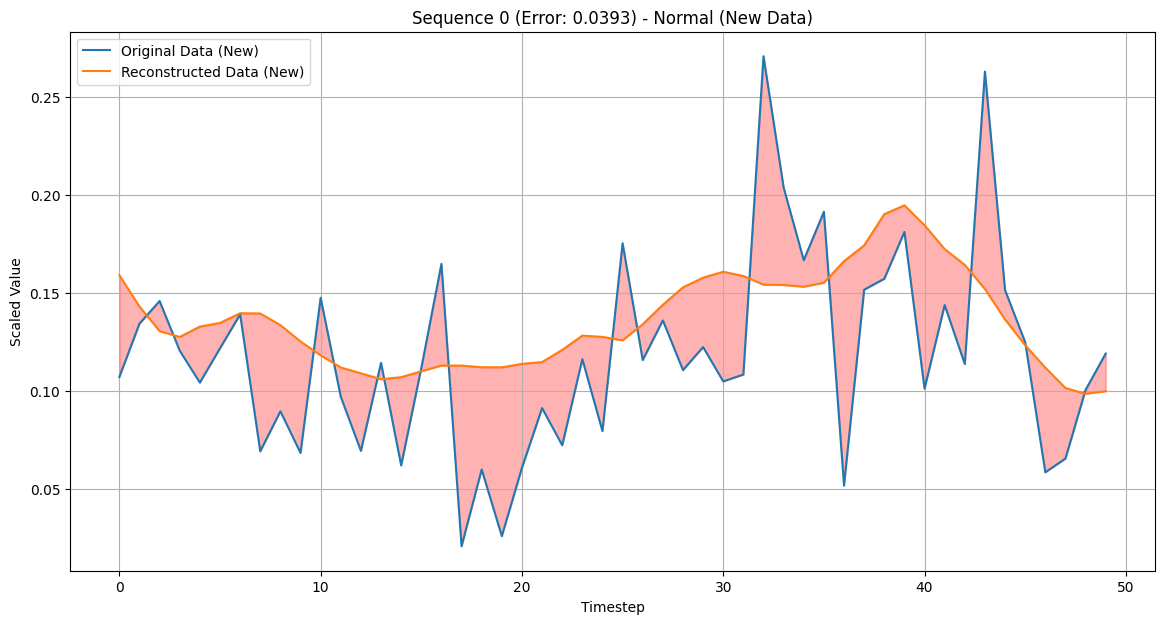

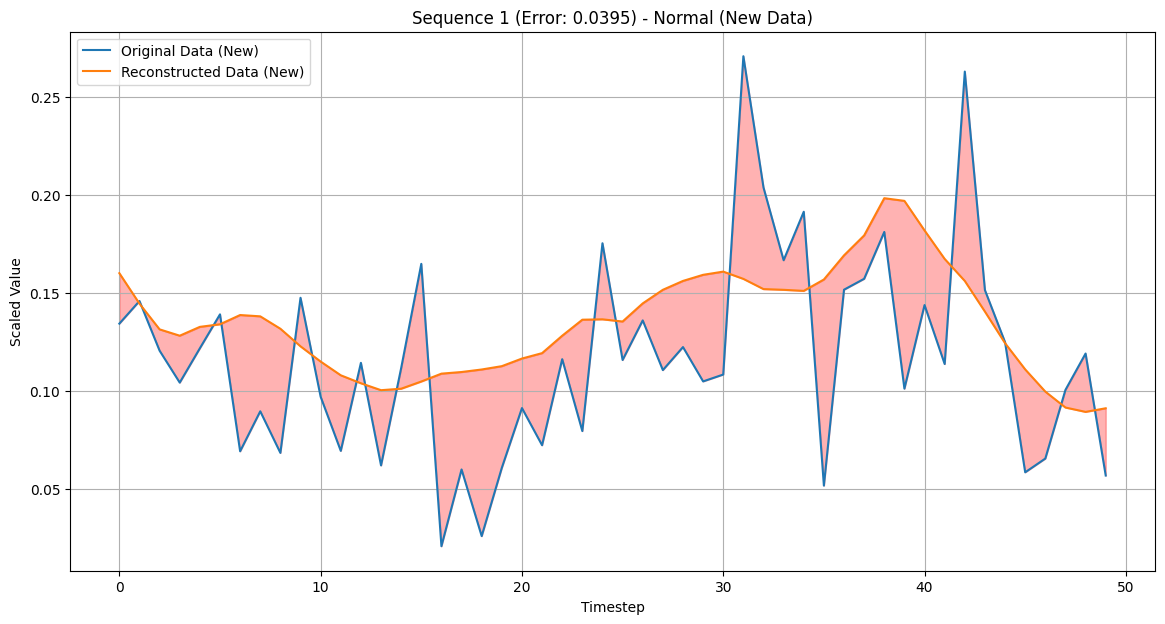

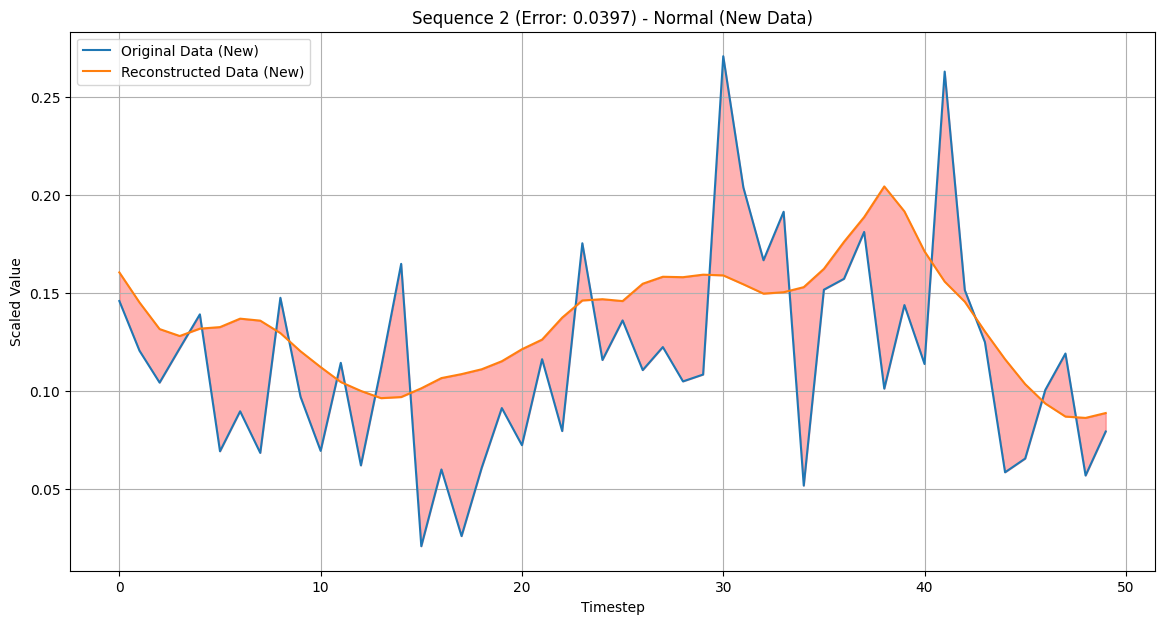


--- Visualizing Anomalous Sequences (New Data) ---


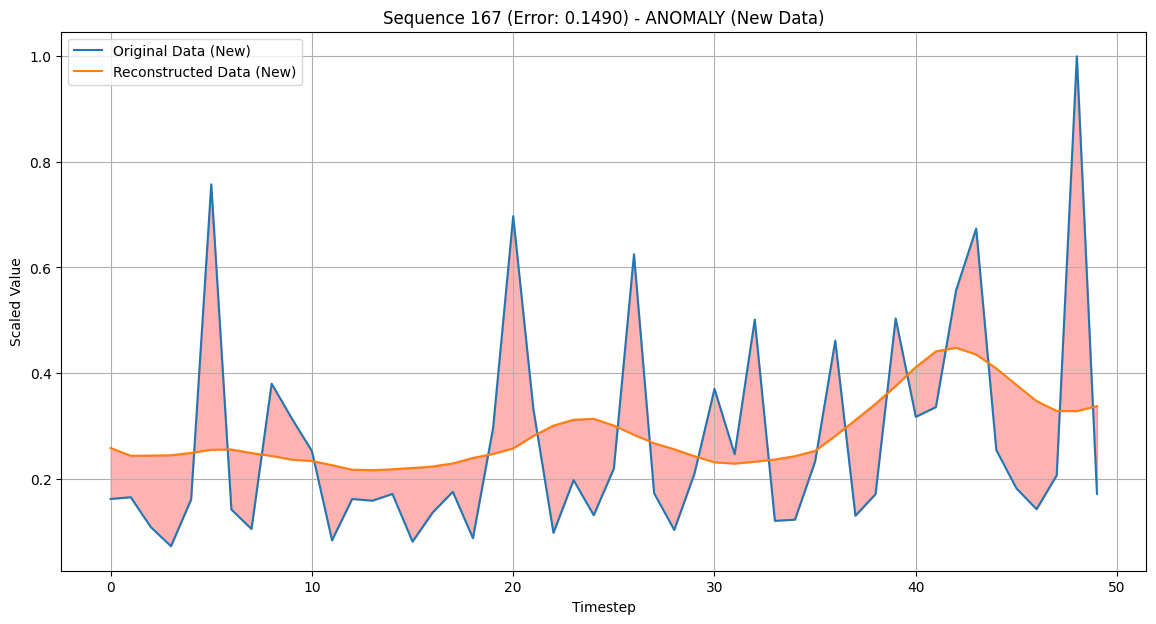

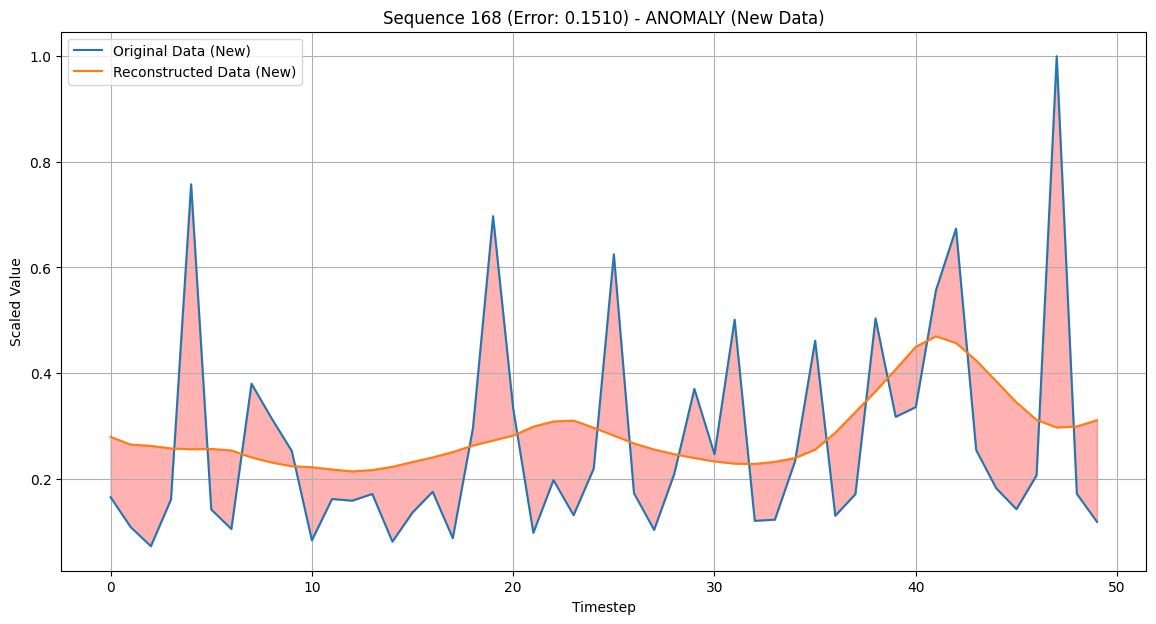

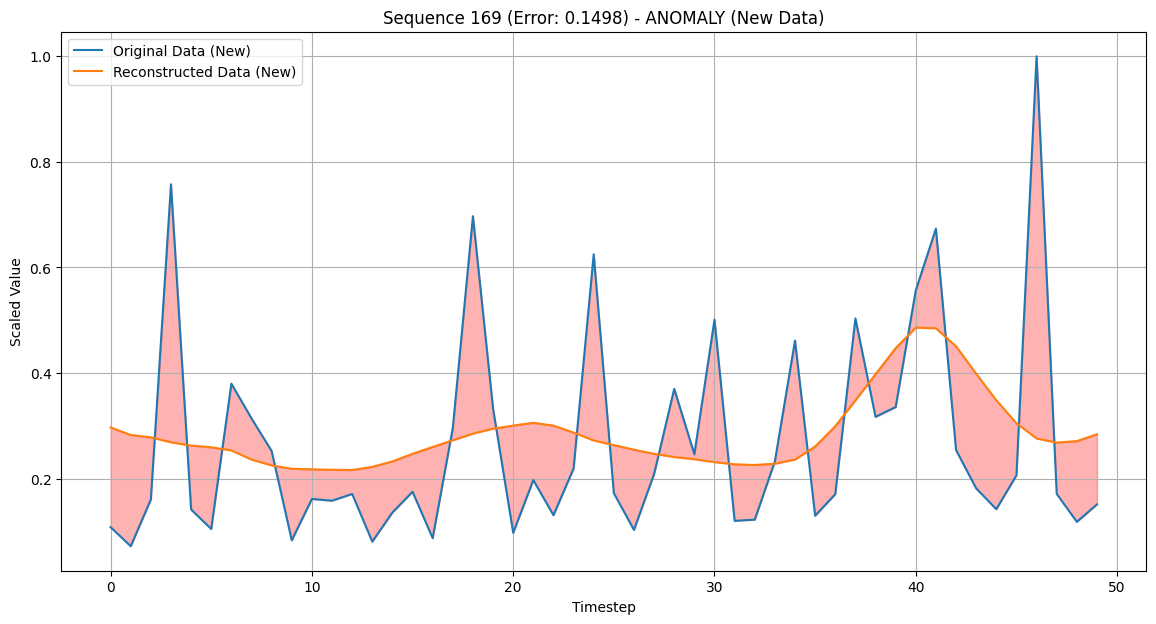

In [ ]:
# Set a threshold for anomaly detection (e.g., 95th percentile of errors) for new data
THRESHOLD_NEW = np.percentile(reconstruction_errors_new, 95)
print(f"Anomaly threshold for new data set at the 95th percentile: {THRESHOLD_NEW:.4f}")

# Find indices of sequences with high reconstruction error (potential anomalies) in new data
anomaly_indices_new = np.where(reconstruction_errors_new > THRESHOLD_NEW)[0]
print(f"Found {len(anomaly_indices_new)} potential anomalies in new data based on the threshold.")

# Function to plot original, reconstructed, and highlight anomalies for new data
def plot_reconstruction_new(index, is_anomaly=False):
    original = X_train_new[index].flatten()
    reconstructed = reconstructed_sequences_new[index].flatten()
    error = reconstruction_errors_new[index]

    plt.figure(figsize=(14, 7))
    plt.plot(original, label='Original Data (New)')
    plt.plot(reconstructed, label='Reconstructed Data (New)')
    plt.title(f'Sequence {index} (Error: {error:.4f}) - ' + ('ANOMALY (New Data)' if is_anomaly else 'Normal (New Data)'))
    plt.xlabel('Timestep')
    plt.ylabel('Scaled Value')
    plt.legend()
    plt.grid(True)
    plt.fill_between(range(len(original)), original, reconstructed, color='red', alpha=0.3, label='Reconstruction Error Area')
    plt.show()

# Plot a few normal sequences from the new data
print("\n--- Visualizing Normal Sequences (New Data) ---")
normal_indices_new = np.where(reconstruction_errors_new <= THRESHOLD_NEW)[0]
for i in range(min(3, len(normal_indices_new))):
    plot_reconstruction_new(normal_indices_new[i], is_anomaly=False)

# Plot a few anomalous sequences from the new data (if any are found)
if len(anomaly_indices_new) > 0:
    print("\n--- Visualizing Anomalous Sequences (New Data) ---")
    for i in range(min(3, len(anomaly_indices_new))):
        plot_reconstruction_new(anomaly_indices_new[i], is_anomaly=True)
else:
    print("\nNo anomalies found above the set threshold in the new training data.")

Once you have loaded your new dataset and selected the relevant time series column, you can proceed with the subsequent steps of preprocessing, sequence creation, model building, and anomaly detection as demonstrated previously. You may need to adapt the preprocessing steps (e.g., handling missing values, specific column selection) based on the characteristics of your new data.